# 05 — CodeBERT Fine-Tuning with Custom Classification Head

Notebook ini menggunakan **CodeBERT** sebagai transformer-based model utama.

Model backbone:

```text
microsoft/codebert-base
```

Perbedaannya dari fine-tuning standar:
- Menggunakan custom classification head.
- Menggunakan learning rate berbeda untuk backbone dan classification head.
- Best checkpoint dipilih berdasarkan validation F1-score.
- Threshold final dipilih berdasarkan validation F1-score.

## Preprocessing

Preprocessing dilakukan oleh tokenizer CodeBERT:
1. Source code diubah menjadi token.
2. Token dikonversi menjadi `input_ids`.
3. Dibuat `attention_mask`.
4. Input dipotong atau dipadding sampai 512 token.

## Arsitektur

```text
Source code
→ CodeBERT tokenizer
→ CodeBERT pretrained backbone
→ CLS representation
→ Dropout
→ Dense 256 + GELU
→ Dropout
→ Output 2 classes
```

Backbone CodeBERT ikut di-fine-tune, tetapi dengan learning rate kecil. Classification head dilatih dengan learning rate lebih besar.

In [1]:
!pip -q install transformers accelerate scikit-learn

## 1. Import library dan mount Google Drive

In [2]:
import os
from google.colab import drive

if os.path.exists("/content/drive/MyDrive"):
    print("Google Drive already mounted at /content/drive")
    DRIVE_ROOT = "/content/drive"
else:
    try:
        drive.mount("/content/drive", force_remount=True)
        DRIVE_ROOT = "/content/drive"
    except ValueError:
        drive.mount("/content/gdrive", force_remount=True)
        DRIVE_ROOT = "/content/gdrive"

print("DRIVE_ROOT:", DRIVE_ROOT)

Mounted at /content/drive
DRIVE_ROOT: /content/drive


In [3]:
import sys
import json
import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

PROJECT_DIR = os.path.join(DRIVE_ROOT, "MyDrive", "FP AI")
SRC_DIR = os.path.join(PROJECT_DIR, "src")
sys.path.append(SRC_DIR)

try:
    from config import *
    print("config.py loaded.")
except Exception:
    print("config.py not found. Using fallback paths.")
    RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")
    PROCESSED_DIR = os.path.join(PROJECT_DIR, "data", "processed")
    SPLIT_DIR = os.path.join(PROJECT_DIR, "data", "splits")
    EDA_DIR = os.path.join(PROJECT_DIR, "outputs", "eda")
    MODEL_DIR = os.path.join(PROJECT_DIR, "outputs", "models")
    PREDICTION_DIR = os.path.join(PROJECT_DIR, "outputs", "predictions")
    METRIC_DIR = os.path.join(PROJECT_DIR, "outputs", "metrics")
    FIGURE_DIR = os.path.join(PROJECT_DIR, "outputs", "figures")
    RANDOM_STATE = 42

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CODEBERT_MODEL_NAME = "microsoft/codebert-base"
CODEBERT_DIR = os.path.join(MODEL_DIR, "codebert")
CODEBERT_BEST_DIR = os.path.join(CODEBERT_DIR, "best_model")
CODEBERT_FINAL_DIR = os.path.join(CODEBERT_DIR, "final_model")
CODEBERT_FIGURE_DIR = os.path.join(FIGURE_DIR, "codebert")

for folder in [CODEBERT_DIR, CODEBERT_BEST_DIR, CODEBERT_FINAL_DIR, CODEBERT_FIGURE_DIR, PREDICTION_DIR, METRIC_DIR]:
    os.makedirs(folder, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("Device:", device)
print("CODEBERT_FINAL_DIR:", CODEBERT_FINAL_DIR)

config.py loaded.
PROJECT_DIR: /content/drive/MyDrive/FP AI
Device: cuda
CODEBERT_FINAL_DIR: /content/drive/MyDrive/FP AI/outputs/models/codebert/final_model


## 2. Load train, validation, dan test set

In [4]:
train_df = pd.read_csv(os.path.join(SPLIT_DIR, "train.csv"))
valid_df = pd.read_csv(os.path.join(SPLIT_DIR, "valid.csv"))
test_df = pd.read_csv(os.path.join(SPLIT_DIR, "test.csv"))

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

print("\nTrain label:")
print(train_df["label"].value_counts().sort_index())
print("\nValid label:")
print(valid_df["label"].value_counts().sort_index())
print("\nTest label:")
print(test_df["label"].value_counts().sort_index())

display(train_df.head())

Train: (744, 11)
Valid: (164, 11)
Test : (172, 11)

Train label:
label
0    369
1    375
Name: count, dtype: int64

Valid label:
label
0    84
1    80
Name: count, dtype: int64

Test label:
label
0    87
1    85
Name: count, dtype: int64


,problem_id,group_id,leakage_group,code_hash,code,label,dataset_origin,source_type,status_in_folder,LLM,hf_split
0,p02954,open_p02954,lg_00002,8e5962d3a5bad724b2ce411df1df0b85,s = input()\nn = len(s)\ncounts = [0] * n\nfor i in range(n):\n if s[i] == 'R':\n counts[(i + 1) % n] += 1\n else:\n counts[(i - 1) % n]...,1,open,ai,Generate,GEMINI,test
1,p02640,open_p02640,lg_00003,ddc7e61578e1d8cb72612564cad62a4f,"def solve(X, Y):\n if X == Y:\n return ""Yes""\n elif X < Y:\n return ""No""\n else:\n return ""Yes"" if Y % 2 == 0 and X - Y // 2 >...",1,open,ai,Generate,LLAMA,train
2,p03643,open_p03643,lg_00004,26cf1b3f9816aecfdc848762c0d935ca,"print(f""ABC{int(input())}"")",1,open,ai,Generate,CODESTRAL,train
3,p02769,open_p02769,lg_00005,5bfbfaa6bfdd59987faa29095f73be93,"import sys\nread = sys.stdin.read\nreadline = sys.stdin.readline\nreadlines = sys.stdin.readlines\n\nMOD = 10**9+7\n\nfac = [1, 1]\nf_inv = [1, 1]\ninv = [0...",0,open,human,Accepted,Human,train
4,p02685,open_p02685,lg_00007,df6147be35a53f74db70decb96459dd2,"#factorial\nMOD = 998244353\nN = 1000000\nmodinv_t = [0, 1]\nmodfact_t = [1, 1]\nmodfactinv_t = [1, 1]\nfor i in range(2,N+1):\n modfact_t.append(modfact_t...",0,open,human,Accepted,Human,train


## 3. Preprocessing — tokenizer CodeBERT dan Dataset

In [5]:
MAX_LENGTH = 512
BATCH_SIZE = 8

tokenizer = AutoTokenizer.from_pretrained(CODEBERT_MODEL_NAME)

class CodeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        code = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            code,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

train_dataset = CodeDataset(train_df["code"], train_df["label"], tokenizer, max_length=MAX_LENGTH)
valid_dataset = CodeDataset(valid_df["code"], valid_df["label"], tokenizer, max_length=MAX_LENGTH)
test_dataset = CodeDataset(test_df["code"], test_df["label"], tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch = next(iter(train_loader))
print("input_ids:", sample_batch["input_ids"].shape)
print("attention_mask:", sample_batch["attention_mask"].shape)
print("labels:", sample_batch["labels"].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

input_ids: torch.Size([8, 512])
attention_mask: torch.Size([8, 512])
labels: torch.Size([8])


## 4. Build model — CodeBERT dengan custom classification head

In [6]:
class CodeBERTCustomClassifier(nn.Module):
    def __init__(self, model_name, hidden_dim=256, dropout_rate=0.3, num_labels=2):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout_1 = nn.Dropout(dropout_rate)
        self.classifier_dense = nn.Linear(hidden_size, hidden_dim)
        self.activation = nn.GELU()
        self.dropout_2 = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # CodeBERT/RoBERTa memakai representasi token pertama sebagai sequence representation
        cls_representation = outputs.last_hidden_state[:, 0, :]

        x = self.dropout_1(cls_representation)
        x = self.classifier_dense(x)
        x = self.activation(x)
        x = self.dropout_2(x)
        logits = self.output(x)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(label_smoothing=0.03)
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

model = CodeBERTCustomClassifier(
    model_name=CODEBERT_MODEL_NAME,
    hidden_dim=256,
    dropout_rate=0.3,
    num_labels=2
)

model.to(device)

n_total_params = sum(p.numel() for p in model.parameters())
n_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Total parameters:", n_total_params)
print("Trainable parameters:", n_trainable_params)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CodeBERTCustomClassifier(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerN

### Penjelasan layer

Model ini terdiri dari:
- **CodeBERT backbone**: pretrained transformer untuk source code.
- **CLS representation**: representasi ringkas dari keseluruhan kode.
- **Dropout**: mengurangi overfitting.
- **Dense 256 + GELU**: custom classification head.
- **Output layer 2 kelas**: human-written code atau AI-generated code.

Backbone CodeBERT bukan dibuat dari awal. Backbone berasal dari pretrained model. Yang dibuat manual adalah classification head di atasnya.

## 5. Training setup

In [7]:
EPOCHS = 8
BACKBONE_LR = 1e-5
HEAD_LR = 5e-5
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0

# Learning rate kecil untuk backbone, lebih besar untuk custom head
optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(), "lr": BACKBONE_LR},
        {
            "params": list(model.dropout_1.parameters())
            + list(model.classifier_dense.parameters())
            + list(model.dropout_2.parameters())
            + list(model.output.parameters()),
            "lr": HEAD_LR
        },
    ],
    weight_decay=WEIGHT_DECAY
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.10 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Total steps:", total_steps)
print("Warmup steps:", warmup_steps)
print("Backbone LR:", BACKBONE_LR)
print("Head LR:", HEAD_LR)

Total steps: 744
Warmup steps: 74
Backbone LR: 1e-05
Head LR: 5e-05


## 6. Helper evaluasi dan threshold tuning

In [8]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.05, 0.951, 0.01)
    rows = []

    for th in thresholds:
        y_pred = (y_proba >= th).astype(int)
        rows.append({
            "threshold": float(th),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
    return float(best_row["threshold"]), threshold_df, best_row

def evaluate_loader(model, loader, threshold=0.5):
    model.eval()

    losses = []
    y_true_all = []
    y_proba_all = []

    start_time = time.time()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs["loss"]
            logits = outputs["logits"]

            probs = torch.softmax(logits, dim=1)[:, 1]

            losses.append(loss.item())
            y_true_all.extend(labels.detach().cpu().numpy().tolist())
            y_proba_all.extend(probs.detach().cpu().numpy().tolist())

    end_time = time.time()

    y_true = np.array(y_true_all)
    y_proba = np.array(y_proba_all)
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "inference_time_seconds": float(end_time - start_time),
        "inference_time_per_sample_seconds": float((end_time - start_time) / max(len(y_true), 1))
    }

    cm = confusion_matrix(y_true, y_pred)

    return metrics, y_true, y_proba, y_pred, cm

## 7. Fine-tuning CodeBERT custom head

In [9]:
history = []
best_val_f1 = -1
best_val_loss = float("inf")
best_epoch = None
best_threshold = 0.5

start_train = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()

    train_losses = []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs["loss"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        scheduler.step()

        train_losses.append(loss.item())

    # Validation probability first, then tune threshold
    val_default_metrics, val_true, val_proba, _, _ = evaluate_loader(model, valid_loader, threshold=0.5)
    epoch_best_threshold, threshold_df, threshold_best_row = find_best_threshold(val_true, val_proba)

    val_metrics, _, _, val_pred, val_cm = evaluate_loader(
        model,
        valid_loader,
        threshold=epoch_best_threshold
    )

    train_loss = float(np.mean(train_losses))

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "best_threshold": epoch_best_threshold
    }

    history.append(row)

    print(f"Epoch {epoch}/{EPOCHS}")
    print(json.dumps(row, indent=4))

    improved = False
    if val_metrics["f1"] > best_val_f1:
        improved = True
    elif val_metrics["f1"] == best_val_f1 and val_metrics["loss"] < best_val_loss:
        improved = True

    if improved:
        best_val_f1 = val_metrics["f1"]
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_threshold = epoch_best_threshold

        torch.save(model.state_dict(), os.path.join(CODEBERT_BEST_DIR, "custom_codebert_state.pt"))

        best_config = {
            "model": "CodeBERT-CustomHead",
            "base_model": CODEBERT_MODEL_NAME,
            "hidden_dim": 256,
            "dropout_rate": 0.3,
            "num_labels": 2,
            "max_length": MAX_LENGTH,
            "best_epoch": best_epoch,
            "best_validation_f1": best_val_f1,
            "best_validation_loss": best_val_loss,
            "best_threshold": best_threshold
        }

        with open(os.path.join(CODEBERT_BEST_DIR, "custom_codebert_config.json"), "w") as f:
            json.dump(best_config, f, indent=4)

        tokenizer.save_pretrained(CODEBERT_BEST_DIR)

        print("Best model updated.")

end_train = time.time()
training_time_seconds = end_train - start_train

print("Training completed.")
print("Training time seconds:", training_time_seconds)
print("Best epoch:", best_epoch)
print("Best validation F1:", best_val_f1)
print("Best threshold:", best_threshold)

Epoch 1/8
{
    "epoch": 1,
    "train_loss": 0.6714637225033134,
    "val_loss": 0.5155701083796365,
    "val_accuracy": 0.7621951219512195,
    "val_precision": 0.7029702970297029,
    "val_recall": 0.8875,
    "val_f1": 0.7845303867403315,
    "val_roc_auc": 0.842857142857143,
    "best_threshold": 0.45000000000000007
}
Best model updated.
Epoch 2/8
{
    "epoch": 2,
    "train_loss": 0.42588030554914985,
    "val_loss": 0.4424123622122265,
    "val_accuracy": 0.8658536585365854,
    "val_precision": 0.7959183673469388,
    "val_recall": 0.975,
    "val_f1": 0.8764044943820225,
    "val_roc_auc": 0.9254464285714287,
    "best_threshold": 0.6200000000000001
}
Best model updated.
Epoch 3/8
{
    "epoch": 3,
    "train_loss": 0.28313152235682293,
    "val_loss": 0.65422073751688,
    "val_accuracy": 0.8536585365853658,
    "val_precision": 0.7857142857142857,
    "val_recall": 0.9625,
    "val_f1": 0.8651685393258427,
    "val_roc_auc": 0.9397321428571428,
    "best_threshold": 0.90000

## 8. Load best checkpoint dan evaluasi final

In [10]:
# Load best model
model.load_state_dict(torch.load(os.path.join(CODEBERT_BEST_DIR, "custom_codebert_state.pt"), map_location=device))
model.to(device)

valid_metrics, valid_true, valid_proba, valid_pred, valid_cm = evaluate_loader(
    model,
    valid_loader,
    threshold=best_threshold
)

test_metrics, test_true, test_proba, test_pred, test_cm = evaluate_loader(
    model,
    test_loader,
    threshold=best_threshold
)

print("Validation metrics:")
print(json.dumps(valid_metrics, indent=4))
print("Validation confusion matrix:")
print(valid_cm)

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=4))
print("Test confusion matrix:")
print(test_cm)

print("\nTest classification report:")
print(classification_report(test_true, test_pred, target_names=["Human", "AI"], zero_division=0))

Validation metrics:
{
    "loss": 0.49401915144352687,
    "accuracy": 0.8963414634146342,
    "precision": 0.8705882352941177,
    "recall": 0.925,
    "f1": 0.896969696969697,
    "roc_auc": 0.9492559523809524,
    "inference_time_seconds": 5.027121305465698,
    "inference_time_per_sample_seconds": 0.030653178691864014
}
Validation confusion matrix:
[[73 11]
 [ 6 74]]

Test metrics:
{
    "loss": 0.37663182514635,
    "accuracy": 0.9244186046511628,
    "precision": 0.9390243902439024,
    "recall": 0.9058823529411765,
    "f1": 0.9221556886227545,
    "roc_auc": 0.9695740365111561,
    "inference_time_seconds": 5.216179847717285,
    "inference_time_per_sample_seconds": 0.030326627021612124
}
Test confusion matrix:
[[82  5]
 [ 8 77]]

Test classification report:
              precision    recall  f1-score   support

       Human       0.91      0.94      0.93        87
          AI       0.94      0.91      0.92        85

    accuracy                           0.92       172
   ma

## 9. Simpan model final, predictions, dan metrics

In [11]:
# Save final custom model assets
torch.save(model.state_dict(), os.path.join(CODEBERT_FINAL_DIR, "custom_codebert_state.pt"))
tokenizer.save_pretrained(CODEBERT_FINAL_DIR)

custom_config = {
    "model": "CodeBERT-CustomHead",
    "base_model": CODEBERT_MODEL_NAME,
    "hidden_dim": 256,
    "dropout_rate": 0.3,
    "num_labels": 2,
    "max_length": MAX_LENGTH,
    "best_epoch": int(best_epoch),
    "best_threshold": float(best_threshold),
    "backbone_learning_rate": BACKBONE_LR,
    "head_learning_rate": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "architecture": "CodeBERT backbone + CLS + Dropout + Dense 256 GELU + Dropout + Linear output"
}

with open(os.path.join(CODEBERT_FINAL_DIR, "custom_codebert_config.json"), "w") as f:
    json.dump(custom_config, f, indent=4)

# Keep threshold file in usual location
threshold_path = os.path.join(CODEBERT_DIR, "best_threshold.json")
with open(threshold_path, "w") as f:
    json.dump({
        "model": "CodeBERT-CustomHead",
        "best_threshold": float(best_threshold),
        "best_epoch": int(best_epoch),
        "selected_by": "best_validation_f1"
    }, f, indent=4)

# Save history
history_df = pd.DataFrame(history)
history_path = os.path.join(METRIC_DIR, "codebert_training_history.csv")
history_df.to_csv(history_path, index=False)

# Save predictions
valid_pred_df = valid_df.copy()
valid_pred_df["y_true"] = valid_true
valid_pred_df["y_proba_ai"] = valid_proba
valid_pred_df["y_pred"] = valid_pred
valid_pred_df["model"] = "CodeBERT-CustomHead"

test_pred_df = test_df.copy()
test_pred_df["y_true"] = test_true
test_pred_df["y_proba_ai"] = test_proba
test_pred_df["y_pred"] = test_pred
test_pred_df["model"] = "CodeBERT-CustomHead"

valid_prediction_path = os.path.join(PREDICTION_DIR, "codebert_valid_predictions.csv")
test_prediction_path = os.path.join(PREDICTION_DIR, "codebert_test_predictions.csv")

valid_pred_df.to_csv(valid_prediction_path, index=False)
test_pred_df.to_csv(test_prediction_path, index=False)

# Save metrics
metrics_json = {
    "model": "CodeBERT-CustomHead",
    "base_model": CODEBERT_MODEL_NAME,
    "validation": valid_metrics,
    "test": test_metrics,
    "validation_confusion_matrix": valid_cm.tolist(),
    "test_confusion_matrix": test_cm.tolist(),
    "best_threshold": float(best_threshold),
    "best_epoch": int(best_epoch),
    "training_time_seconds": float(training_time_seconds),
    "validation_inference_time_seconds": float(valid_metrics["inference_time_seconds"]),
    "test_inference_time_seconds": float(test_metrics["inference_time_seconds"]),
    "validation_inference_time_per_sample_seconds": float(valid_metrics["inference_time_per_sample_seconds"]),
    "test_inference_time_per_sample_seconds": float(test_metrics["inference_time_per_sample_seconds"]),
    "n_train": int(len(train_df)),
    "n_valid": int(len(valid_df)),
    "n_test": int(len(test_df)),
    "trainable_parameters": int(n_trainable_params),
    "total_parameters": int(n_total_params),
    "max_length": int(MAX_LENGTH),
    "selection_strategy": "best checkpoint selected by validation F1 with tuned threshold",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

metrics_json_path = os.path.join(METRIC_DIR, "codebert_metrics.json")
with open(metrics_json_path, "w") as f:
    json.dump(metrics_json, f, indent=4)

metrics_rows = []
for split_name, metric_dict in [("validation", valid_metrics), ("test", test_metrics)]:
    metrics_rows.append({
        "model": "CodeBERT-CustomHead",
        "split": split_name,
        "loss": metric_dict["loss"],
        "accuracy": metric_dict["accuracy"],
        "precision": metric_dict["precision"],
        "recall": metric_dict["recall"],
        "f1": metric_dict["f1"],
        "roc_auc": metric_dict["roc_auc"],
        "threshold": best_threshold,
        "training_time_seconds": float(training_time_seconds),
        "inference_time_seconds": metric_dict["inference_time_seconds"],
        "inference_time_per_sample_seconds": metric_dict["inference_time_per_sample_seconds"],
        "trainable_parameters": int(n_trainable_params),
        "selection_strategy": "best_validation_f1"
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_csv_path = os.path.join(METRIC_DIR, "codebert_metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=False)

print("Saved final model:", CODEBERT_FINAL_DIR)
print("Saved predictions:", valid_prediction_path, test_prediction_path)
print("Saved metrics:", metrics_json_path, metrics_csv_path)
display(metrics_df)

Saved final model: /content/drive/MyDrive/FP AI/outputs/models/codebert/final_model
Saved predictions: /content/drive/MyDrive/FP AI/outputs/predictions/codebert_valid_predictions.csv /content/drive/MyDrive/FP AI/outputs/predictions/codebert_test_predictions.csv
Saved metrics: /content/drive/MyDrive/FP AI/outputs/metrics/codebert_metrics.json /content/drive/MyDrive/FP AI/outputs/metrics/codebert_metrics.csv


,model,split,loss,accuracy,precision,recall,f1,roc_auc,threshold,training_time_seconds,inference_time_seconds,inference_time_per_sample_seconds,trainable_parameters,selection_strategy
0,CodeBERT-CustomHead,validation,0.494019,0.896341,0.870588,0.925000,0.896970,0.949256,0.95,721.969437,5.027121,0.030653,124843010,best_validation_f1
1,CodeBERT-CustomHead,test,0.376632,0.924419,0.939024,0.905882,0.922156,0.969574,0.95,721.969437,5.216180,0.030327,124843010,best_validation_f1


## 10. Plot training history dan confusion matrix

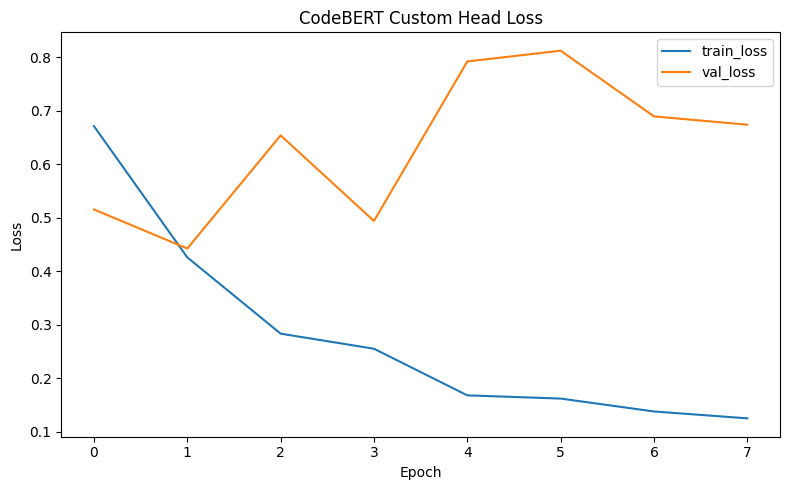

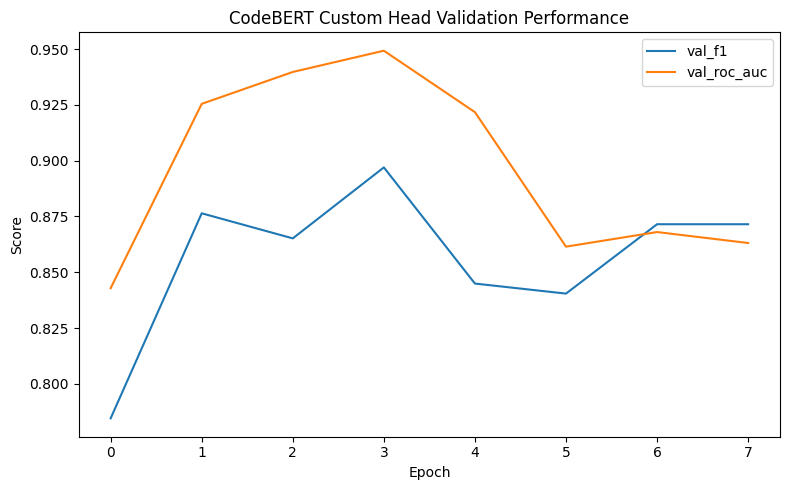

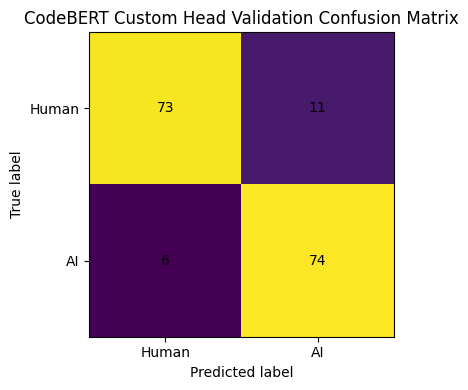

Saved: /content/drive/MyDrive/FP AI/outputs/figures/codebert/codebert_custom_validation_confusion_matrix.png


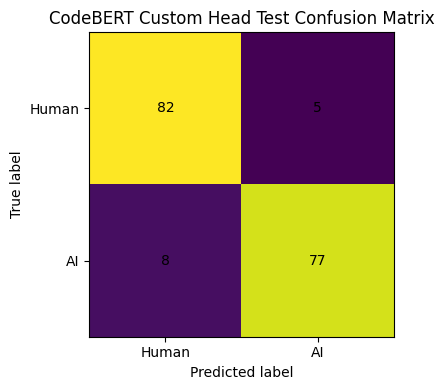

Saved: /content/drive/MyDrive/FP AI/outputs/figures/codebert/codebert_custom_test_confusion_matrix.png


In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["train_loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("CodeBERT Custom Head Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(CODEBERT_FIGURE_DIR, "codebert_custom_head_loss_curve.png")
plt.savefig(loss_plot_path, dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["val_f1"], label="val_f1")
plt.plot(history_df["val_roc_auc"], label="val_roc_auc")
plt.title("CodeBERT Custom Head Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()

perf_plot_path = os.path.join(CODEBERT_FIGURE_DIR, "codebert_custom_head_validation_performance.png")
plt.savefig(perf_plot_path, dpi=200)
plt.show()

def plot_confusion_matrix(cm, title, path):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Human", "AI"])
    plt.yticks([0, 1], ["Human", "AI"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    print("Saved:", path)

valid_cm_path = os.path.join(CODEBERT_FIGURE_DIR, "codebert_custom_validation_confusion_matrix.png")
test_cm_path = os.path.join(CODEBERT_FIGURE_DIR, "codebert_custom_test_confusion_matrix.png")

plot_confusion_matrix(valid_cm, "CodeBERT Custom Head Validation Confusion Matrix", valid_cm_path)
plot_confusion_matrix(test_cm, "CodeBERT Custom Head Test Confusion Matrix", test_cm_path)

## 11. Interpretasi singkat CodeBERT custom head

In [13]:
gap_f1 = valid_metrics["f1"] - test_metrics["f1"]

interpretation = f'''
CodeBERT custom head digunakan sebagai model transformer utama. Backbone yang digunakan adalah microsoft/codebert-base, sedangkan classification head dibuat secara manual berupa Dropout, Dense 256 dengan aktivasi GELU, Dropout, dan output layer dua kelas.

Pada validation set, model memperoleh F1-score sebesar {valid_metrics["f1"]:.4f}. Pada test set, model memperoleh F1-score sebesar {test_metrics["f1"]:.4f}. Selisih F1 validation dan test sebesar {gap_f1:.4f}.

Model ini tetap termasuk transformer-based fine-tuning karena backbone CodeBERT ikut dilatih pada dataset penelitian. Perubahan utama dibanding fine-tuning standar adalah custom classification head dan learning rate berbeda antara backbone dan head.
'''.strip()

interpretation_path = os.path.join(METRIC_DIR, "codebert_interpretation.txt")
with open(interpretation_path, "w") as f:
    f.write(interpretation)

print(interpretation)
print("\nSaved:", interpretation_path)

CodeBERT custom head digunakan sebagai model transformer utama. Backbone yang digunakan adalah microsoft/codebert-base, sedangkan classification head dibuat secara manual berupa Dropout, Dense 256 dengan aktivasi GELU, Dropout, dan output layer dua kelas.

Pada validation set, model memperoleh F1-score sebesar 0.8970. Pada test set, model memperoleh F1-score sebesar 0.9222. Selisih F1 validation dan test sebesar -0.0252.

Model ini tetap termasuk transformer-based fine-tuning karena backbone CodeBERT ikut dilatih pada dataset penelitian. Perubahan utama dibanding fine-tuning standar adalah custom classification head dan learning rate berbeda antara backbone dan head.

Saved: /content/drive/MyDrive/FP AI/outputs/metrics/codebert_interpretation.txt


## 12. Final output check

In [14]:
required_outputs = [
    os.path.join(CODEBERT_FINAL_DIR, "custom_codebert_state.pt"),
    os.path.join(CODEBERT_FINAL_DIR, "custom_codebert_config.json"),
    threshold_path,
    valid_prediction_path,
    test_prediction_path,
    history_path,
    metrics_json_path,
    metrics_csv_path,
    loss_plot_path,
    perf_plot_path,
    valid_cm_path,
    test_cm_path,
    interpretation_path
]

print("Final output check:")
for path in required_outputs:
    print(os.path.basename(path), "=>", os.path.exists(path))

assert all(os.path.exists(path) for path in required_outputs)

print("\nNotebook 05 CodeBERT custom head completed successfully.")

Final output check:
custom_codebert_state.pt => True
custom_codebert_config.json => True
best_threshold.json => True
codebert_valid_predictions.csv => True
codebert_test_predictions.csv => True
codebert_training_history.csv => True
codebert_metrics.json => True
codebert_metrics.csv => True
codebert_custom_head_loss_curve.png => True
codebert_custom_head_validation_performance.png => True
codebert_custom_validation_confusion_matrix.png => True
codebert_custom_test_confusion_matrix.png => True
codebert_interpretation.txt => True

Notebook 05 CodeBERT custom head completed successfully.
